# Agents Last Exam — Data Exploration
[agents-last-exam/agents-last-exam](https://huggingface.co/datasets/agents-last-exam/agents-last-exam)

In [1]:
# %pip install -q datasets pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
hf_token = 'token'

In [4]:
ds = load_dataset("agents-last-exam/agents-last-exam", token=hf_token)

In [5]:
ds

DatasetDict({
    v1.0: Dataset({
        features: ['task_id', 'title', 'summary', 'category', 'subdomain', 'task_split', 'task_prompt', 'agent_must_do', 'software', 'input_files', 'taxonomy', 'source_repo_path'],
        num_rows: 153
    })
})

In [12]:
df = ds['v1.0'].to_pandas()

In [13]:
print(f"Rows: {len(df)}  |  Columns: {list(df.columns)}")

Rows: 153  |  Columns: ['task_id', 'title', 'summary', 'category', 'subdomain', 'task_split', 'task_prompt', 'agent_must_do', 'software', 'input_files', 'taxonomy', 'source_repo_path']


## Schema

In [14]:
df.dtypes

task_id                str
title                  str
summary                str
category               str
subdomain              str
task_split             str
task_prompt            str
agent_must_do       object
software            object
input_files         object
taxonomy            object
source_repo_path       str
dtype: object

In [15]:
df[["task_id", "title", "category", "subdomain", "task_split"]].head(10)

,task_id,title,category,subdomain,task_split
0,agriculture_env/crop_rotation_d02,Crop Rotation Audit for Stable Parcels,agriculture_env,Precision Agriculture,near-term
1,agriculture_env/ndvi_zonal_statistics_d02,Sentinel-2 NDVI Zonal Statistics,agriculture_env,Precision Agriculture,full-spectrum
2,business_finance/american_option_pricing_ls,American Option Pricing via Longstaff-Schwartz,business_finance,Quantitative Finance & Trading,full-spectrum
3,business_finance/ar_full_1500,Annual Report Full Extraction (1500 files),business_finance,Accounting & Finance,last-exam
4,business_finance/ar_full_300,Annual Report Full Extraction (300 files),business_finance,Accounting & Finance,full-spectrum
5,business_finance/basel_operational_risk_bia_cn,Basel Operational Risk BIA Classification,business_finance,Actuarial & Risk Modeling,full-spectrum
6,business_finance/bpmn_category_governance_rest...,Flowable BPMN Category Governance Restructurin...,business_finance,Enterprise Analytics & Planning,last-exam
7,business_finance/bpmn_supply_disruption_l3,Flowable BPMN Supply Disruption L3,business_finance,Enterprise Analytics & Planning,near-term
8,business_finance/digital_marketing_ab_test_ana...,Digital Marketing A/B Test Analysis,business_finance,Sales & Marketing,near-term
9,business_finance/digital_marketing_audience_se...,Digital Marketing Audience Segmentation,business_finance,Sales & Marketing,full-spectrum


## Distributions

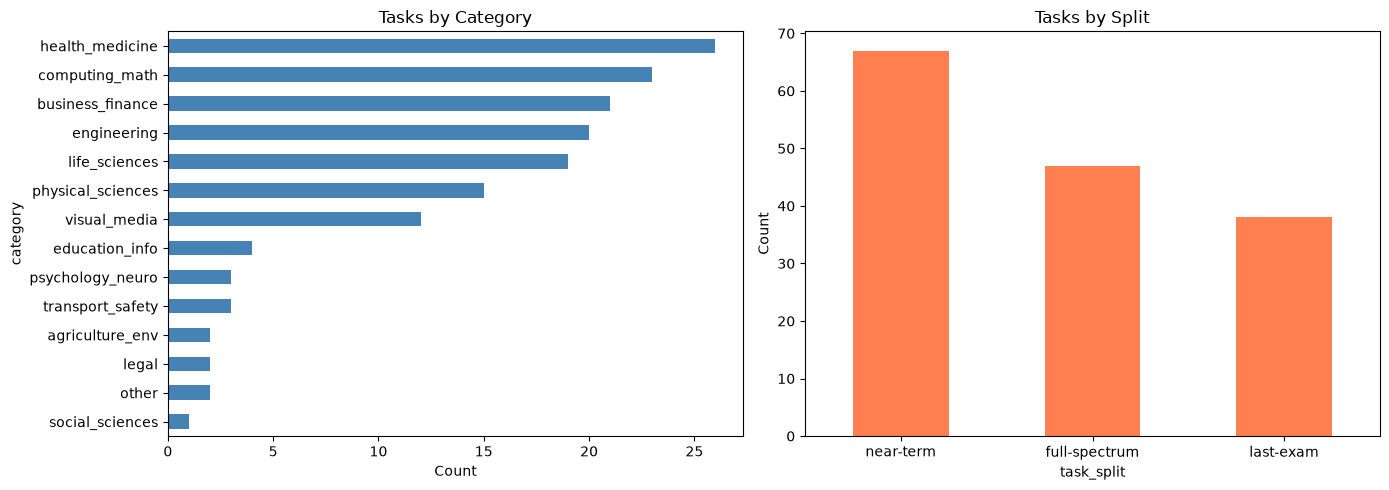

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["category"].value_counts().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Tasks by Category")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

df["task_split"].value_counts().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Tasks by Split")
axes[1].set_xlabel("task_split")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Task Complexity Signals

In [20]:
df["prompt_len"] = df["task_prompt"].str.len()
df["n_must_do"] = df["agent_must_do"].apply(len)
df["n_input_files"] = df["input_files"].apply(len)
df["n_software"] = df["software"].apply(len)

df[["prompt_len", "n_must_do", "n_input_files", "n_software"]].describe().round(2)

,prompt_len,n_must_do,n_input_files,n_software
count,153.00,153.00,153.00,153.00
mean,1548.61,4.52,4.02,3.05
std,740.11,1.41,2.30,1.94
min,502.00,0.00,0.00,0.00
25%,1020.00,4.00,3.00,1.00
50%,1359.00,4.00,4.00,3.00
75%,1829.00,5.00,5.00,4.00
max,5843.00,9.00,14.00,9.00


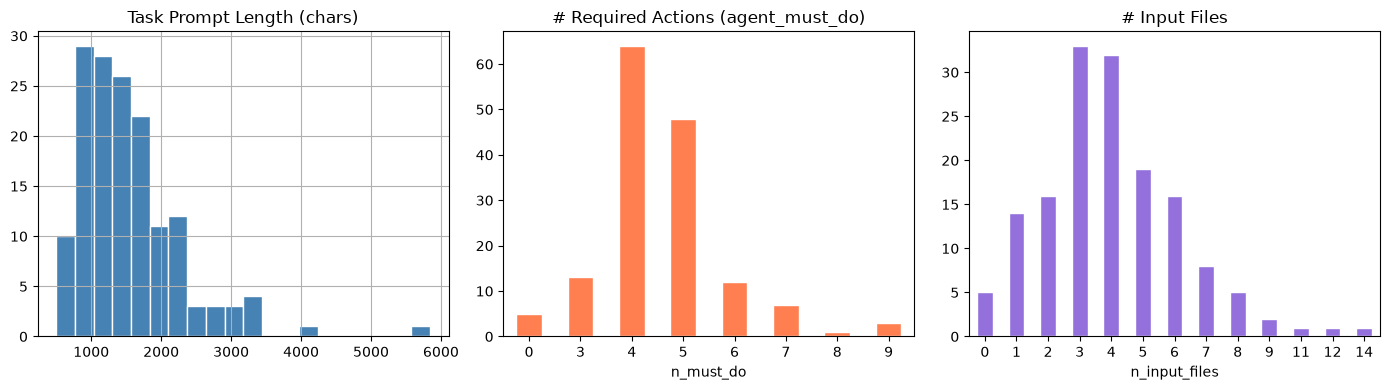

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df["prompt_len"].hist(bins=20, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Task Prompt Length (chars)")

df["n_must_do"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("# Required Actions (agent_must_do)")
axes[1].tick_params(axis="x", rotation=0)

df["n_input_files"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="mediumpurple", edgecolor="white")
axes[2].set_title("# Input Files")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Inspect a Task

In [19]:
row = df.iloc[0]

print(f"Title:      {row['title']}")
print(f"Category:   {row['category']} / {row['subdomain']}")
print(f"Split:      {row['task_split']}")
print(f"Software:   {row['software']}")
print(f"Must-do:    {row['agent_must_do']}")
print(f"Input files:{row['input_files']}")
print(f"\nSummary:\n{row['summary']}")
print(f"\nPrompt (first 800 chars):\n{row['task_prompt'][:800]}")

Title:      Crop Rotation Audit for Stable Parcels
Category:   agriculture_env / Precision Agriculture
Split:      near-term
Software:   ['Python' 'GeoPandas' 'pandas' 'pyogrio' 'shapely' 'pyproj' 'fiona']
Must-do:    ['Read the staged crop-rotation brief in `input/task_prompt.md` and apply it exactly.'
 'Load the `seq1524_d02` layer from `input/seq1524_d02.gpkg`.'
 'Compute the eight required audit columns for every eligible `id_lcp`.'
 'Write `output/eligible_units.gpkg` with preserved original columns and geometry plus the audit fields.'
 'Write `output/flagged_units.gpkg` as the flagged subset with the same schema and exact layer names.']
Input files:[{'name': 'seq1524_d02.gpkg', 'format': 'GeoPackage', 'path': 'input/seq1524_d02.gpkg', 'description': 'Stable agricultural parcel polygons with yearly crop-code columns from 2015 through 2024'}
 {'name': 'task_prompt.md', 'format': 'Markdown', 'path': 'input/task_prompt.md', 'description': 'Agent-visible crop-rotation audit contract w